In [2]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

import python.forces as forces
import python.integrators as integrators
import python.random_matrix as random_matrix 
import python.simulate as simulate
import python.densities as densities

importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities);

---

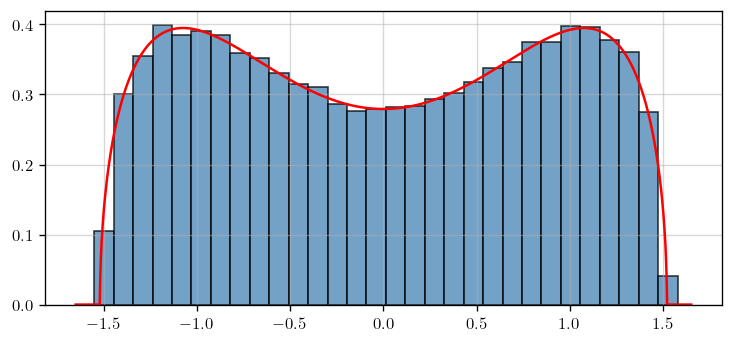

In [5]:
def test_method(method, N = 40, beta = 2.0, T = 5.0, M = 250, potential_name = "quartic"):
    """ 
    Test method by plotting histograms when init with GUE and given quartic potential.
    """

    if (method == "implicit"):
        dt = 0.1
    else:
        dt = 1/(N**2)

    total_steps = int(T/dt)
    init = random_matrix.init_gue_eigenvalues(M, N)
    noise_scale = np.sqrt(2.0*dt/(beta*N))
    pipe = simulate.get_pipeline(method, dt = dt, noise_scale = noise_scale, potential_type = potential_name)

    traj = simulate.simulate_dbm(init, total_steps, pipe)
    particles = simulate.collect_snapshots(traj, total_steps)

    # Quick plotter.
    density_range, limiting_density = densities.get_density(potential_name)

    fig, ax = plt.subplots(figsize = (6, 2.75))
    ax.hist(particles, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
    ax.plot(density_range, limiting_density, color = "red", lw = 1.5)

    plt.show()

test_method("implicit")

Running for 100 steps.


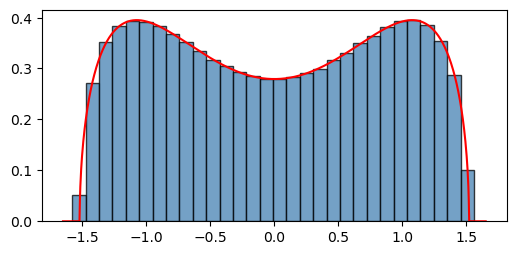

In [17]:
N = 70; beta = 2.0; T = 10.0; M = 2000;
dt = 0.1; total_steps = int(T/dt);
potential_name = "quartic"
print(f"Running for {total_steps} steps.")

init = random_matrix.init_gue_eigenvalues(M, N)
noise_scale = np.sqrt(2.0*dt/(beta*N))

implicit_pipe = simulate.make_implicit_pipeline(dt, noise_scale, beta, potential_name)
traj = simulate.simulate_dbm(init, total_steps, implicit_pipe)
particles = simulate.collect_snapshots(traj, total_steps)

# Quick plotter.
density_range, limiting_density = densities.get_density(potential_name)

fig, ax = plt.subplots(figsize = (6, 2.75))
ax.hist(particles, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax.plot(density_range, limiting_density, color = "red", lw = 1.5)

plt.show()

---


In [14]:
importlib.reload(integrators); importlib.reload(simulate); importlib.reload(forces);
N = 30; beta = 2.0; T = 8.0; M = 100;
dt = 1/(N**2); total_steps = int(T/dt);
potential_name = "quartic"

init = random_matrix.init_gue_eigenvalues(M, N)
noise_scale = np.sqrt(2.0*dt/(beta*N))

mala_pipe = simulate.make_mala_pipeline(dt, noise_scale, potential_name, beta)
traj = simulate.simulate_dbm(init, total_steps, mala_pipe)

accepts = simulate.acceptance_rate(traj)

In [16]:
accepts.shape[0]

7200

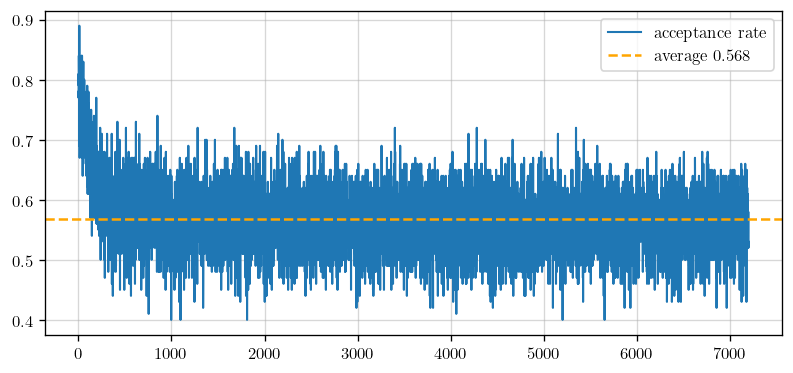

In [22]:
fig, ax = plt.subplots()
x = list(range(accepts.shape[0]))

ax.plot(x, accepts, label = "acceptance rate")
ax.axhline(np.mean(accepts), color = "orange", linestyle = "--", lw = 1.5, label = f"average {np.mean(accepts):.2f}")

ax.legend(loc = "upper right")
plt.show() 